# Expected Goals (xG) Model
### Built on StatsBomb Open Data | Ramith Vaid | NTU Singapore

This notebook builds, trains, and evaluates an Expected Goals (xG) model using StatsBomb coordinate event data.

xG is the probability that a shot results in a goal, given the circumstances of the shot. It is the core analytical metric used by Stats Perform (Opta), StatsBomb, and every major football data provider.

**Approach:**
1. Extract all shots from the 2022 FIFA World Cup (64 matches)
2. Engineer features from raw coordinate data
3. Train a Logistic Regression baseline and a Random Forest model
4. Evaluate with Log Loss and Brier Score
5. Validate against StatsBomb's own xG values
6. Generate match-level xG timelines

**Data source:** StatsBomb open data (statsbombpy)  
**Pitch dimensions:** 120 × 80 (StatsBomb standard)

In [1]:
import pandas as pd
import numpy as np
import math
import warnings
warnings.filterwarnings('ignore')

from statsbombpy import sb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch

print('All libraries imported successfully.')

All libraries imported successfully.


## 1. Data Collection

Loading all 64 matches from the 2022 FIFA World Cup and extracting shot events.

In [2]:
# Load all 2022 World Cup matches
matches = sb.matches(competition_id=43, season_id=106)
print(f'Total matches: {len(matches)}')

all_shots = []

for i, match_id in enumerate(matches['match_id'].tolist()):
    df = sb.events(match_id=match_id)
    shots = df[df['type'] == 'Shot'].copy()
    shots['match_id'] = match_id
    
    # Get preceding events context
    all_shots.append(shots)
    
    if (i + 1) % 10 == 0:
        print(f'  Loaded {i+1}/{len(matches)} matches...')

shots_raw = pd.concat(all_shots, ignore_index=True)
print(f'\nTotal shots collected: {len(shots_raw)}')
print(f'Shot columns: {[c for c in shots_raw.columns if "shot" in c.lower()]}')

Total matches: 64
  Loaded 10/64 matches...
  Loaded 20/64 matches...
  Loaded 30/64 matches...
  Loaded 40/64 matches...
  Loaded 50/64 matches...
  Loaded 60/64 matches...

Total shots collected: 1494
Shot columns: ['pass_assisted_shot_id', 'pass_shot_assist', 'shot_aerial_won', 'shot_body_part', 'shot_end_location', 'shot_first_time', 'shot_freeze_frame', 'shot_key_pass_id', 'shot_one_on_one', 'shot_open_goal', 'shot_outcome', 'shot_statsbomb_xg', 'shot_technique', 'shot_type', 'goalkeeper_shot_saved_to_post', 'shot_deflected', 'shot_saved_to_post', 'shot_redirect', 'goalkeeper_shot_saved_off_target', 'shot_saved_off_target', 'shot_follows_dribble']


## 2. Feature Engineering

Extracting tactical and spatial features from raw coordinate data.

**Features:**
- `distance_to_goal` — Euclidean distance from shot location to goal centre
- `angle_to_goal` — angle subtended by the goal from shot location
- `is_header` — whether the shot was headed
- `is_strong_foot` — dominant foot used (right foot = 1)
- `is_first_time` — shot taken first time (no touch)
- `is_one_on_one` — shot from a one-on-one situation
- `is_open_play` — shot from open play (vs set piece)
- `is_penalty` — penalty kick
- `is_free_kick` — direct free kick
- `under_pressure` — player under pressure when shooting
- `x_coord` — x coordinate (raw)
- `y_coord` — y coordinate (raw)

In [3]:
GOAL_CENTER = (120.0, 40.0)
GOAL_LEFT   = (120.0, 36.0)
GOAL_RIGHT  = (120.0, 44.0)

def distance_to_goal(x, y):
    """Euclidean distance from shot location to goal centre."""
    return math.sqrt((GOAL_CENTER[0] - x)**2 + (GOAL_CENTER[1] - y)**2)

def angle_to_goal(x, y):
    """
    Angle subtended by the goal from the shot location.
    Uses the law of cosines on the triangle formed by shot location
    and the two goalposts.
    """
    # Vectors from shot location to each post
    a = math.sqrt((GOAL_LEFT[0] - x)**2  + (GOAL_LEFT[1] - y)**2)
    b = math.sqrt((GOAL_RIGHT[0] - x)**2 + (GOAL_RIGHT[1] - y)**2)
    # Width of goal
    c = 8.0  # goal width in pitch units
    
    # Law of cosines: c^2 = a^2 + b^2 - 2ab*cos(angle)
    cos_angle = (a**2 + b**2 - c**2) / (2 * a * b)
    cos_angle = max(-1.0, min(1.0, cos_angle))  # clamp for numerical stability
    return math.degrees(math.acos(cos_angle))

def extract_features(shots_df):
    """Extract all features from raw shot data."""
    features = []
    
    for _, row in shots_df.iterrows():
        # Location
        loc = row.get('location', None)
        if not isinstance(loc, (list, tuple)) or len(loc) < 2:
            continue
        x, y = float(loc[0]), float(loc[1])
        
        # Outcome
        outcome = row.get('shot_outcome', None)
        if isinstance(outcome, dict):
            outcome = outcome.get('name', None)
        is_goal = 1 if outcome == 'Goal' else 0
        
        # Body part
        body_part = row.get('shot_body_part', None)
        if isinstance(body_part, dict):
            body_part = body_part.get('name', None)
        is_header   = 1 if body_part == 'Head' else 0
        is_right_foot = 1 if body_part == 'Right Foot' else 0
        
        # Shot type
        shot_type = row.get('shot_type', None)
        if isinstance(shot_type, dict):
            shot_type = shot_type.get('name', None)
        is_open_play = 1 if shot_type == 'Open Play' else 0
        is_penalty   = 1 if shot_type == 'Penalty'   else 0
        is_free_kick = 1 if shot_type == 'Free Kick' else 0
        
        # Technique
        technique = row.get('shot_technique', None)
        if isinstance(technique, dict):
            technique = technique.get('name', None)
        is_volley = 1 if technique in ['Volley', 'Half Volley'] else 0
        
        # Situational
        is_first_time = 1 if row.get('shot_first_time', False) == True else 0
        is_one_on_one = 1 if row.get('shot_one_on_one', False) == True else 0
        under_pressure = 1 if row.get('under_pressure', False) == True else 0
        
        # Spatial features
        dist  = distance_to_goal(x, y)
        angle = angle_to_goal(x, y)
        
        # StatsBomb xG (for validation)
        sb_xg = row.get('shot_statsbomb_xg', None)
        
        features.append({
            # Target
            'is_goal':        is_goal,
            # Spatial
            'distance':       dist,
            'angle':          angle,
            'x':              x,
            'y':              y,
            # Body part
            'is_header':      is_header,
            'is_right_foot':  is_right_foot,
            # Shot type
            'is_open_play':   is_open_play,
            'is_penalty':     is_penalty,
            'is_free_kick':   is_free_kick,
            # Technique
            'is_volley':      is_volley,
            # Situational
            'is_first_time':  is_first_time,
            'is_one_on_one':  is_one_on_one,
            'under_pressure': under_pressure,
            # Validation
            'sb_xg':          sb_xg,
            # Metadata
            'match_id':       row.get('match_id', None),
            'team':           row.get('team', None),
            'player':         row.get('player', None),
            'minute':         row.get('minute', None),
        })
    
    return pd.DataFrame(features)

shots_df = extract_features(shots_raw)
print(f'Feature matrix shape: {shots_df.shape}')
print(f'Goals: {shots_df["is_goal"].sum()} / {len(shots_df)} shots ({shots_df["is_goal"].mean()*100:.1f}%)')
print()
print(shots_df[['distance', 'angle', 'is_header', 'is_penalty', 'is_open_play', 'is_goal']].describe().round(2))

Feature matrix shape: (1494, 19)
Goals: 195 / 1494 shots (13.1%)

       distance    angle  is_header  is_penalty  is_open_play  is_goal
count   1494.00  1494.00    1494.00     1494.00       1494.00  1494.00
mean      18.18    26.44       0.17        0.04          0.93     0.13
std        8.14    16.01       0.37        0.20          0.26     0.34
min        1.32     0.00       0.00        0.00          0.00     0.00
25%       11.90    15.68       0.00        0.00          1.00     0.00
50%       17.06    20.76       0.00        0.00          1.00     0.00
75%       24.26    34.40       0.00        0.00          1.00     0.00
max       70.83   143.92       1.00        1.00          1.00     1.00


## 3. Exploratory Data Analysis

Understanding the relationship between features and goal probability.

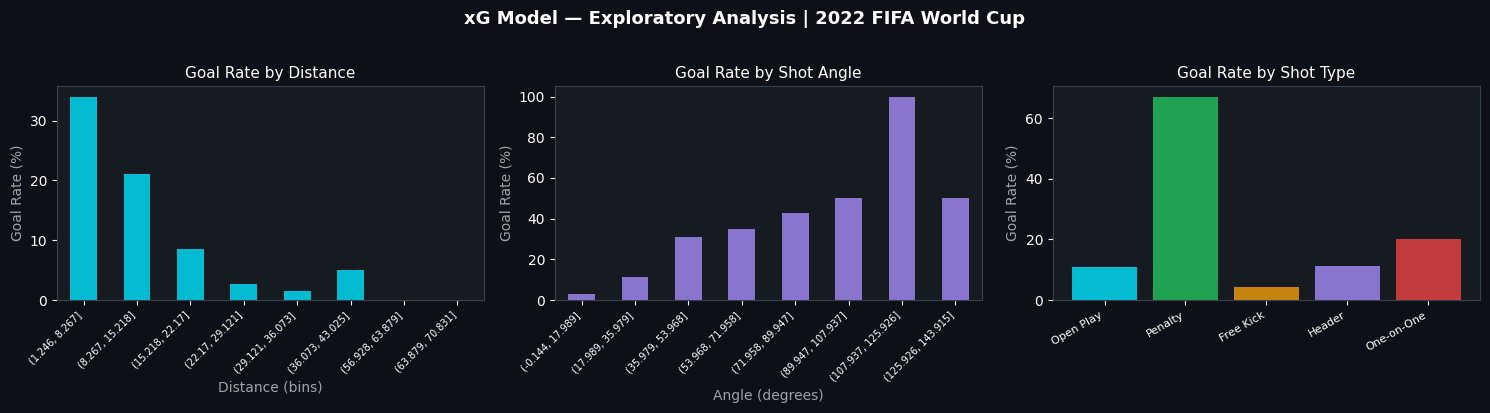

EDA chart saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#0d1117')

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# 1. Goal rate by distance bin
shots_df['dist_bin'] = pd.cut(shots_df['distance'], bins=10)
goal_by_dist = shots_df.groupby('dist_bin', observed=True)['is_goal'].mean() * 100
goal_by_dist.plot(kind='bar', ax=axes[0], color='#00e5ff', alpha=0.8)
axes[0].set_title('Goal Rate by Distance', color='white', fontsize=11)
axes[0].set_xlabel('Distance (bins)', color='#9ca3af')
axes[0].set_ylabel('Goal Rate (%)', color='#9ca3af')
axes[0].set_xticklabels([str(b) for b in goal_by_dist.index], rotation=45, ha='right', fontsize=7)

# 2. Goal rate by angle bin
shots_df['angle_bin'] = pd.cut(shots_df['angle'], bins=8)
goal_by_angle = shots_df.groupby('angle_bin', observed=True)['is_goal'].mean() * 100
goal_by_angle.plot(kind='bar', ax=axes[1], color='#a78bfa', alpha=0.8)
axes[1].set_title('Goal Rate by Shot Angle', color='white', fontsize=11)
axes[1].set_xlabel('Angle (degrees)', color='#9ca3af')
axes[1].set_ylabel('Goal Rate (%)', color='#9ca3af')
axes[1].set_xticklabels([str(b) for b in goal_by_angle.index], rotation=45, ha='right', fontsize=7)

# 3. Goal rate by shot type
type_cols = ['is_open_play', 'is_penalty', 'is_free_kick', 'is_header', 'is_one_on_one']
type_labels = ['Open Play', 'Penalty', 'Free Kick', 'Header', 'One-on-One']
type_rates = [shots_df[shots_df[c] == 1]['is_goal'].mean() * 100 for c in type_cols]
colors = ['#00e5ff', '#22c55e', '#f59e0b', '#a78bfa', '#ef4444']
bars = axes[2].bar(type_labels, type_rates, color=colors, alpha=0.8)
axes[2].set_title('Goal Rate by Shot Type', color='white', fontsize=11)
axes[2].set_ylabel('Goal Rate (%)', color='#9ca3af')
axes[2].set_xticklabels(type_labels, rotation=30, ha='right', fontsize=8)

plt.suptitle('xG Model — Exploratory Analysis | 2022 FIFA World Cup', 
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight', 
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('EDA chart saved.')

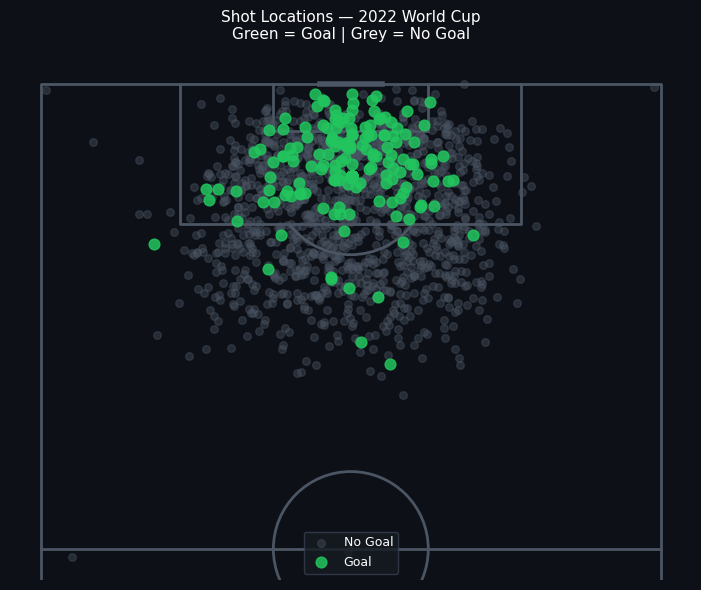

Shot map saved.


In [5]:
# Shot map — where goals come from vs non-goals
pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#0d1117', 
                      line_color='#4B5563', half=True)
fig, ax = pitch.draw(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')

non_goals = shots_df[shots_df['is_goal'] == 0]
goals     = shots_df[shots_df['is_goal'] == 1]

pitch.scatter(non_goals['x'], non_goals['y'], ax=ax, s=30,
              color='#4b5563', alpha=0.4, zorder=2, label='No Goal')
pitch.scatter(goals['x'], goals['y'], ax=ax, s=60,
              color='#22c55e', alpha=0.85, zorder=3, label='Goal')

ax.set_title('Shot Locations — 2022 World Cup\nGreen = Goal | Grey = No Goal',
             color='white', fontsize=11, pad=10)
ax.legend(loc='lower center', facecolor='#161b22', edgecolor='#374151',
          labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig('shot_map.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('Shot map saved.')

## 4. Model Training

Training three models: Logistic Regression (baseline), Random Forest, and Gradient Boosting.

In [6]:
# Feature columns
FEATURES = [
    'distance', 'angle', 'x', 'y',
    'is_header', 'is_right_foot',
    'is_open_play', 'is_penalty', 'is_free_kick',
    'is_volley', 'is_first_time', 'is_one_on_one',
    'under_pressure'
]

TARGET = 'is_goal'

# Remove rows with missing features
model_df = shots_df[FEATURES + [TARGET, 'sb_xg']].dropna(subset=FEATURES)
print(f'Model dataset: {len(model_df)} shots')
print(f'Goal rate: {model_df[TARGET].mean()*100:.1f}%')

X = model_df[FEATURES]
y = model_df[TARGET]

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Model dataset: 1494 shots
Goal rate: 13.1%
Train: 1195 | Test: 299


In [7]:
# Model 1: Logistic Regression (baseline)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# Model 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Model 3: Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    min_samples_leaf=5, random_state=42
)
gb_model.fit(X_train, y_train)
gb_probs = gb_model.predict_proba(X_test)[:, 1]

# StatsBomb xG on test set (for comparison)
sb_xg_test = model_df.loc[X_test.index, 'sb_xg'].values

print('Models trained.')

Models trained.


## 5. Evaluation

Evaluating all three models against StatsBomb's own xG values using Log Loss, Brier Score, and AUC-ROC.

In [8]:
results = {}

models = {
    'Logistic Regression': lr_probs,
    'Random Forest':       rf_probs,
    'Gradient Boosting':   gb_probs,
    'StatsBomb xG':        sb_xg_test,
}

print(f'{"Model":<25} {"Log Loss":>10} {"Brier Score":>12} {"AUC-ROC":>10}')
print('─' * 60)

for name, probs in models.items():
    # Handle NaN in StatsBomb xG
    mask = ~np.isnan(probs)
    p = probs[mask]
    t = y_test.values[mask]
    
    ll  = log_loss(t, p)
    bs  = brier_score_loss(t, p)
    auc = roc_auc_score(t, p)
    
    results[name] = {'log_loss': ll, 'brier': bs, 'auc': auc}
    print(f'{name:<25} {ll:>10.4f} {bs:>12.4f} {auc:>10.4f}')

print()
print('Note: Lower Log Loss and Brier Score = better. Higher AUC = better.')
print('StatsBomb xG is the industry benchmark — aim to match or beat it.')

Model                       Log Loss  Brier Score    AUC-ROC
────────────────────────────────────────────────────────────
Logistic Regression           0.2963       0.0850     0.8017
Random Forest                 0.2857       0.0834     0.8376
Gradient Boosting             0.3074       0.0899     0.8229
StatsBomb xG                  0.2791       0.0810     0.8457

Note: Lower Log Loss and Brier Score = better. Higher AUC = better.
StatsBomb xG is the industry benchmark — aim to match or beat it.


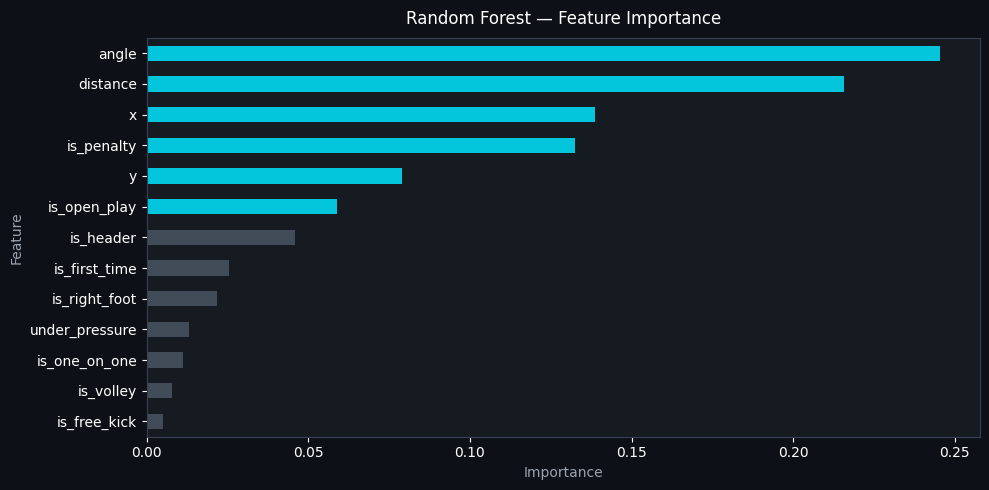

Feature importance chart saved.


In [9]:
# Feature importance — Random Forest
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#374151')

colors = ['#00e5ff' if v > importances.median() else '#4b5563' for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.set_title('Random Forest — Feature Importance', color='white', fontsize=12, pad=10)
ax.set_xlabel('Importance', color='#9ca3af')
ax.set_ylabel('Feature', color='#9ca3af')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('Feature importance chart saved.')

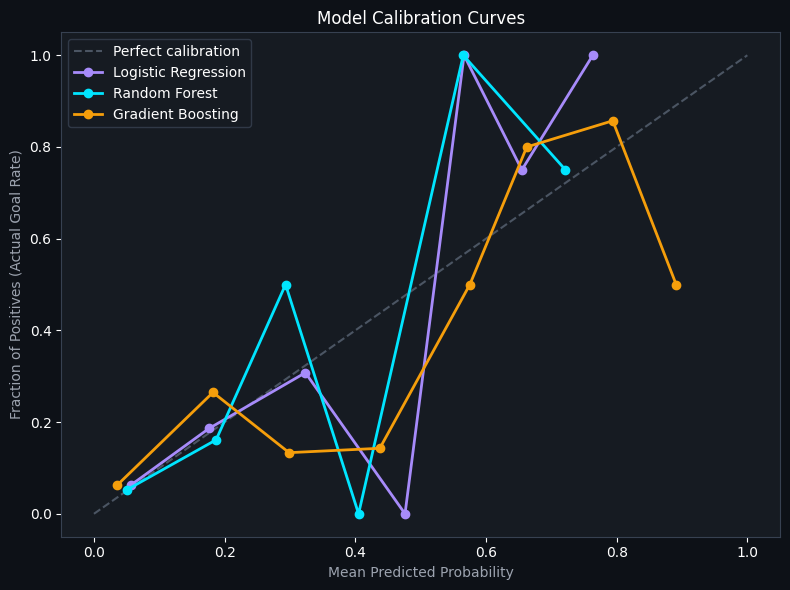

In [10]:
# Calibration plot — how well do predicted probabilities match actual goal rates?
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#374151')

# Perfect calibration line
ax.plot([0, 1], [0, 1], linestyle='--', color='#4b5563', label='Perfect calibration')

plot_models = {
    'Logistic Regression': (lr_probs,  '#a78bfa'),
    'Random Forest':       (rf_probs,  '#00e5ff'),
    'Gradient Boosting':   (gb_probs,  '#f59e0b'),
}

for name, (probs, color) in plot_models.items():
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8)
    ax.plot(mean_pred, frac_pos, marker='o', color=color, label=name, linewidth=2)

ax.set_xlabel('Mean Predicted Probability', color='#9ca3af')
ax.set_ylabel('Fraction of Positives (Actual Goal Rate)', color='#9ca3af')
ax.set_title('Model Calibration Curves', color='white', fontsize=12)
ax.legend(facecolor='#161b22', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()

## 6. Comparison with StatsBomb xG

Validating our model's predictions against StatsBomb's proprietary xG values.

Correlation with StatsBomb xG:
  Logistic Regression : 0.8936
  Random Forest       : 0.8966
  Gradient Boosting   : 0.8042


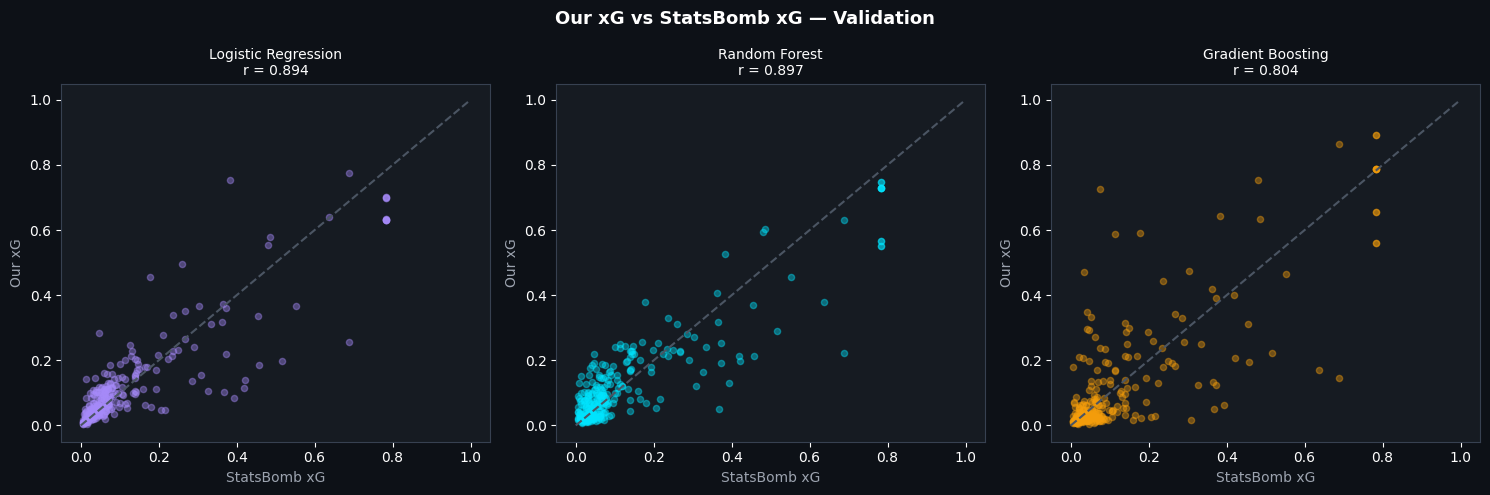

In [11]:
# Correlation between our xG and StatsBomb xG
compare_df = X_test.copy()
compare_df['our_xg_lr']  = lr_probs
compare_df['our_xg_rf']  = rf_probs
compare_df['our_xg_gb']  = gb_probs
compare_df['sb_xg']      = sb_xg_test
compare_df['is_goal']    = y_test.values

compare_df = compare_df.dropna(subset=['sb_xg'])

corr_lr = compare_df['our_xg_lr'].corr(compare_df['sb_xg'])
corr_rf = compare_df['our_xg_rf'].corr(compare_df['sb_xg'])
corr_gb = compare_df['our_xg_gb'].corr(compare_df['sb_xg'])

print('Correlation with StatsBomb xG:')
print(f'  Logistic Regression : {corr_lr:.4f}')
print(f'  Random Forest       : {corr_rf:.4f}')
print(f'  Gradient Boosting   : {corr_gb:.4f}')

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0d1117')

pairs = [
    ('our_xg_lr', 'Logistic Regression', '#a78bfa', corr_lr),
    ('our_xg_rf', 'Random Forest',       '#00e5ff', corr_rf),
    ('our_xg_gb', 'Gradient Boosting',   '#f59e0b', corr_gb),
]

for ax, (col, name, color, corr) in zip(axes, pairs):
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')
    
    ax.scatter(compare_df['sb_xg'], compare_df[col], alpha=0.4, s=20, color=color)
    ax.plot([0, 1], [0, 1], '--', color='#4b5563')
    ax.set_xlabel('StatsBomb xG', color='#9ca3af')
    ax.set_ylabel('Our xG', color='#9ca3af')
    ax.set_title(f'{name}\nr = {corr:.3f}', color='white', fontsize=10)

plt.suptitle('Our xG vs StatsBomb xG — Validation', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xg_validation.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()

## 7. Match-Level xG Timeline

Generating an xG timeline for a specific match — showing how xG accumulated over 90 minutes.

Generating xG timeline for Argentina vs France (WC Final)...


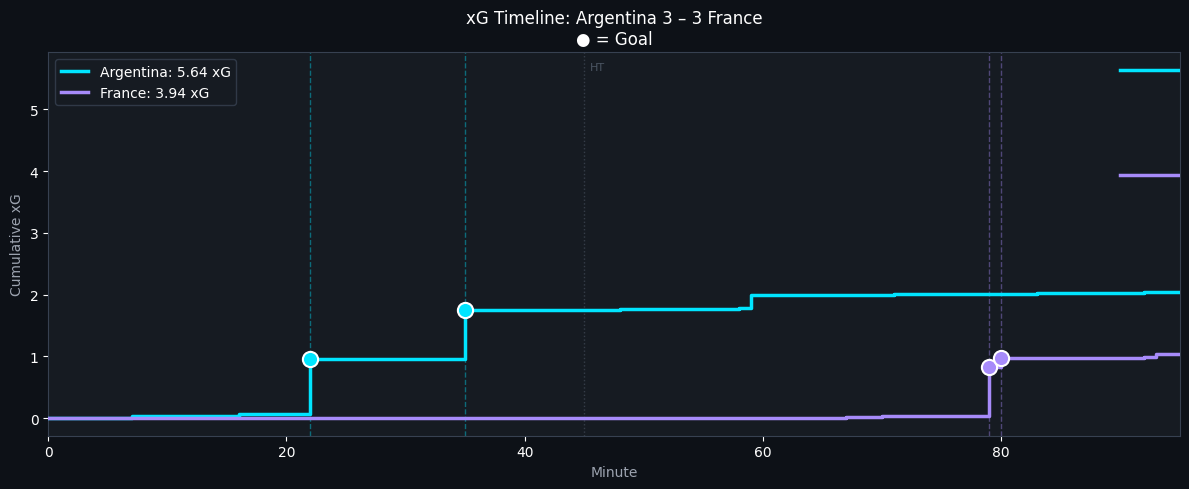

In [12]:
def generate_xg_timeline(match_id: int, model=gb_model):
    """
    Generate an xG timeline for a specific match.
    Shows cumulative xG over time for both teams.
    """
    df = sb.events(match_id=match_id)
    shots = df[df['type'] == 'Shot'].copy()
    shots['match_id'] = match_id
    
    shot_features = extract_features(shots)
    shot_features = shot_features.dropna(subset=FEATURES)
    
    if shot_features.empty:
        print('No shots found.')
        return
    
    # Predict xG
    X_match = shot_features[FEATURES]
    shot_features['our_xg'] = model.predict_proba(X_match)[:, 1]
    
    teams = shot_features['team'].unique().tolist()
    team_colors = {teams[0]: '#00e5ff', teams[1]: '#a78bfa'}
    
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')
    
    for team in teams:
        team_shots = shot_features[shot_features['team'] == team].sort_values('minute')
        team_shots['cumxg'] = team_shots['our_xg'].cumsum()
        
        # Step plot for cumulative xG
        minutes = [0] + team_shots['minute'].tolist() + [90]
        cumxg   = [0] + team_shots['cumxg'].tolist() + [team_shots['cumxg'].iloc[-1]]
        
        ax.step(minutes, cumxg, where='post', color=team_colors[team],
                linewidth=2.5, label=f'{team}: {team_shots["our_xg"].sum():.2f} xG', zorder=3)
        
        # Mark goals
        goals = team_shots[team_shots['is_goal'] == 1]
        for _, g in goals.iterrows():
            ax.axvline(x=g['minute'], color=team_colors[team], 
                      linewidth=1, alpha=0.4, linestyle='--')
            ax.scatter(g['minute'], g['cumxg'], 
                      color=team_colors[team], s=120, zorder=5,
                      edgecolors='white', linewidth=1.5)
    
    ax.axvline(x=45, color='#4b5563', linewidth=1, linestyle=':', alpha=0.6)
    ax.text(45.5, ax.get_ylim()[1]*0.95, 'HT', color='#4b5563', fontsize=8)
    
    ax.set_xlabel('Minute', color='#9ca3af')
    ax.set_ylabel('Cumulative xG', color='#9ca3af')
    ax.set_xlim(0, 95)
    
    # Get match info
    match_info = matches[matches['match_id'] == match_id]
    if not match_info.empty:
        home = match_info['home_team'].values[0]
        away = match_info['away_team'].values[0]
        hs   = match_info['home_score'].values[0]
        as_  = match_info['away_score'].values[0]
        ax.set_title(f'xG Timeline: {home} {hs} – {as_} {away}\n● = Goal', 
                    color='white', fontsize=12)
    
    ax.legend(facecolor='#161b22', edgecolor='#374151', labelcolor='white', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'xg_timeline_{match_id}.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117', edgecolor='none')
    plt.show()
    
    return shot_features

# Generate timeline for Argentina vs France Final
print('Generating xG timeline for Argentina vs France (WC Final)...')
final_shots = generate_xg_timeline(3869685)

## 8. xG Shot Map

Visualising shot locations with xG values encoded as size and colour.

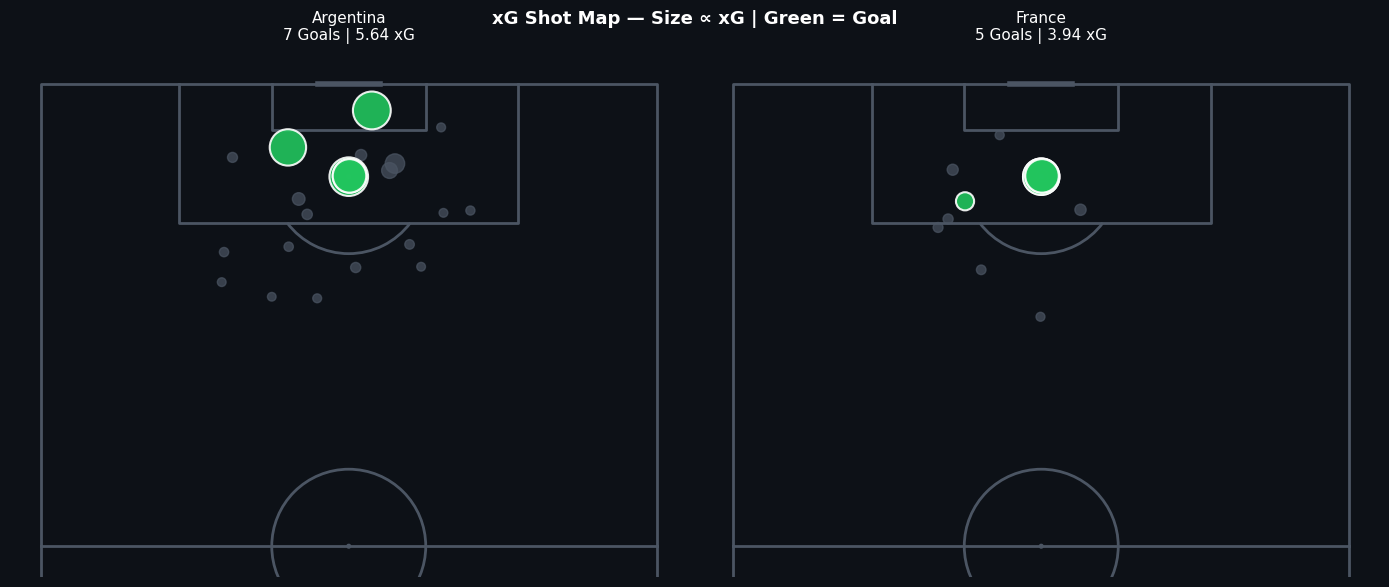

Shot map saved.


In [13]:
def plot_xg_shot_map(match_id: int, model=gb_model):
    """Plot shot map with xG values for a specific match."""
    df = sb.events(match_id=match_id)
    shots = df[df['type'] == 'Shot'].copy()
    shots['match_id'] = match_id
    
    shot_features = extract_features(shots)
    shot_features = shot_features.dropna(subset=FEATURES)
    X_match = shot_features[FEATURES]
    shot_features['our_xg'] = model.predict_proba(X_match)[:, 1]
    
    teams = shot_features['team'].unique().tolist()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#0d1117')
    
    for ax, team in zip(axes, teams[:2]):
        pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#0d1117',
                              line_color='#4B5563', half=True)
        pitch.draw(ax=ax)
        
        team_shots = shot_features[shot_features['team'] == team]
        goals     = team_shots[team_shots['is_goal'] == 1]
        non_goals = team_shots[team_shots['is_goal'] == 0]
        
        # Non-goals sized by xG
        if not non_goals.empty:
            pitch.scatter(non_goals['x'], non_goals['y'], ax=ax,
                         s=non_goals['our_xg'] * 800 + 30,
                         color='#4b5563', alpha=0.7, zorder=2)
        
        # Goals
        if not goals.empty:
            pitch.scatter(goals['x'], goals['y'], ax=ax,
                         s=goals['our_xg'] * 800 + 60,
                         color='#22c55e', alpha=0.9, zorder=3,
                         edgecolors='white', linewidth=1.5)
        
        total_xg = team_shots['our_xg'].sum()
        n_goals  = team_shots['is_goal'].sum()
        ax.set_title(f'{team}\n{n_goals} Goals | {total_xg:.2f} xG',
                    color='white', fontsize=11, pad=10)
    
    plt.suptitle('xG Shot Map — Size ∝ xG | Green = Goal', 
                color='white', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'xg_shotmap_{match_id}.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117', edgecolor='none')
    plt.show()

plot_xg_shot_map(3869685)
print('Shot map saved.')

## 9. Summary

Results and key findings from the xG model.

In [14]:
print('=' * 60)
print('xG MODEL SUMMARY')
print('=' * 60)
print(f'Training data: {len(X_train)} shots | Test data: {len(X_test)} shots')
print(f'Goal rate: {y.mean()*100:.1f}%')
print()
print(f'{"Model":<25} {"Log Loss":>10} {"Brier":>8} {"AUC":>8}')
print('─' * 55)
for name, r in results.items():
    print(f'{name:<25} {r["log_loss"]:>10.4f} {r["brier"]:>8.4f} {r["auc"]:>8.4f}')
print()
print('Top 3 most important features (Random Forest):')
top3 = pd.Series(rf_model.feature_importances_, index=FEATURES).nlargest(3)
for feat, imp in top3.items():
    print(f'  {feat}: {imp:.4f}')
print()
print('Correlation with StatsBomb xG:')
print(f'  Gradient Boosting: {corr_gb:.4f}')
print()
print('Files saved: eda_analysis.png, shot_map.png, feature_importance.png,')
print('             calibration.png, xg_validation.png, xg_timeline_*.png,')
print('             xg_shotmap_*.png')

xG MODEL SUMMARY
Training data: 1195 shots | Test data: 299 shots
Goal rate: 13.1%

Model                       Log Loss    Brier      AUC
───────────────────────────────────────────────────────
Logistic Regression           0.2963   0.0850   0.8017
Random Forest                 0.2857   0.0834   0.8376
Gradient Boosting             0.3074   0.0899   0.8229
StatsBomb xG                  0.2791   0.0810   0.8457

Top 3 most important features (Random Forest):
  angle: 0.2455
  distance: 0.2156
  x: 0.1387

Correlation with StatsBomb xG:
  Gradient Boosting: 0.8042

Files saved: eda_analysis.png, shot_map.png, feature_importance.png,
             calibration.png, xg_validation.png, xg_timeline_*.png,
             xg_shotmap_*.png
